# Stage 3: 神经网络期权定价

- **实验 1**：基础 NN，使用 BS 参数 (S, K, r, T, hv_20d, call_put)，MSE 损失
- **实验 2**：自定义损失（价格绝对偏差 + Heston 定价偏差）
- **测试集**：IO2412（2412 到期期权）

| 输入 | 输出 |
|------|------|
| `full_option_trading_data.csv` | NN(MSE)、NN(自定义) 的 MAE/RMSE/MAPE，作为 stage 4 对照基准 |

In [1]:
import pandas as pd
import numpy as np
from OptionPricingModel import (
    OptionPricingModel,
    extract_expiry_yymm,
    compute_metrics,
    set_seed,
    SEED,
)
from FlexibleMLP import FlexibleMLP, create_combined_loss
from OptionPricingReporter import OptionPricingReporter

set_seed()

In [2]:
# 加载数据，划分训练集(2401-2411)与测试集(2412)
df = pd.read_csv("full_option_trading_data.csv")
df["expiry_yymm"] = df["order_book_id"].apply(extract_expiry_yymm)
train_yymm = [f"24{i:02d}" for i in range(1, 12)]
df_train = df[df["expiry_yymm"].isin(train_yymm)].copy()
df_test = df[df["expiry_yymm"] == "2412"].copy()

def clean_option_data(d):
    d = d.dropna(subset=["underlying_close", "strike_price", "time_to_expire", "risk_free_rate", "close", "hv_20d", "call_put", "iv"])
    d = d[d["time_to_expire"] > 5/365]  # 剔除到期时间小于5天的"末日轮"
    d = d[d["close"] >= 0.2]  # 期权最低结算价 0.2
    d = d[d["hv_20d"] > 1e-6]
    d = d[d["iv"] > 1e-8]  # 排除 iv 缺失或异常小值
    return d

df_train = clean_option_data(df_train)
df_test = clean_option_data(df_test)
print(f"训练集: {len(df_train)}, 测试集: {len(df_test)}")

训练集: 42349, 测试集: 8701


In [3]:
# 特征：S, K, r, T, hv_20d, call_put；目标：close
FEAT_COLS = ["underlying_close", "strike_price", "risk_free_rate", "time_to_expire", "hv_20d", "call_put"]
X_train = df_train[FEAT_COLS].values.astype(np.float64)
y_train = df_train["close"].values.astype(np.float64)
X_test = df_test[FEAT_COLS].values.astype(np.float64)
y_test = df_test["close"].values.astype(np.float64)
print("特征维度:", X_train.shape)

特征维度: (42349, 6)


In [4]:
# Heston 校准（用于实验 2 的自定义损失）及 BS/Heston 基准
model = OptionPricingModel()
pred_bs_test = model.price_bs_batch(df_test)

HESTON_AVAILABLE = False
y_heston_train = None
pred_heston_test = np.full(len(df_test), np.nan)
try:
    model.calibrate_heston(df_train, price_col="close", method="least_squares", max_samples=1500)
    HESTON_AVAILABLE = True
    y_heston_train = model.price_heston_batch(df_train)
    pred_heston_test = model.price_heston_batch(df_test)
    print("Heston 校准完成，y_heston_train 已计算")
except ImportError:
    print("QuantLib 未安装，自定义损失中的 Heston 项将退化为仅价格偏差")

Heston 校准完成，y_heston_train 已计算


## 实验 1：基础 NN（MSE 损失）

In [5]:
nn_mse = FlexibleMLP(
    input_dim=6,
    hidden_dims=[64, 64, 32],
    activation="relu",
    dropout=0.1,
    random_state=SEED,
)
nn_mse.fit(X_train, y_train, epochs=80, batch_size=256, lr=1e-3, verbose=True)
pred_nn_mse_test = nn_mse.predict(X_test)
print("NN(MSE) 测试集:", compute_metrics(y_test, pred_nn_mse_test))

  Epoch 20/80, Loss: 1993.468658
  Epoch 40/80, Loss: 1833.522901
  Epoch 60/80, Loss: 1726.050236
  Epoch 80/80, Loss: 1627.706210
NN(MSE) 测试集: {'MAE': 16.707120574818113, 'RMSE': 29.26594589228957, 'MAPE': 27.653800753564617}


## 实验 2：自定义损失（价格绝对偏差 + Heston 定价偏差）

In [6]:
loss_combined = create_combined_loss(alpha=0.7, beta=0.3)
nn_custom = FlexibleMLP(
    input_dim=6,
    hidden_dims=[64, 64, 32],
    activation="relu",
    dropout=0.1,
    random_state=SEED,
)
if y_heston_train is not None:
    nn_custom.fit(X_train, y_train, loss_fn=loss_combined, y_heston=y_heston_train,
                  epochs=80, batch_size=256, lr=1e-3, verbose=True)
else:
    nn_custom.fit(X_train, y_train, loss_fn=loss_combined, epochs=80, batch_size=256, lr=1e-3, verbose=True)
pred_nn_custom_test = nn_custom.predict(X_test)
print("NN(自定义损失) 测试集:", compute_metrics(y_test, pred_nn_custom_test))

  Epoch 20/80, Loss: 23.904898
  Epoch 40/80, Loss: 22.759184
  Epoch 60/80, Loss: 21.978570
  Epoch 80/80, Loss: 21.197102
NN(自定义损失) 测试集: {'MAE': 20.18860646440111, 'RMSE': 35.245620456462305, 'MAPE': 23.666720208464845}


## 汇总对比（IO2412 测试集）

## OTM / ATM / ITM 分档 Loss 对比（Call / Put 分开，正确虚值实值）

- **ATM**：S/K ∈ [0.97, 1.03]
- **Call**：OTM S/K<0.97，ITM S/K>1.03
- **Put**：OTM S/K>1.03，ITM S/K<0.97

In [7]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ["Arial Unicode MS"]

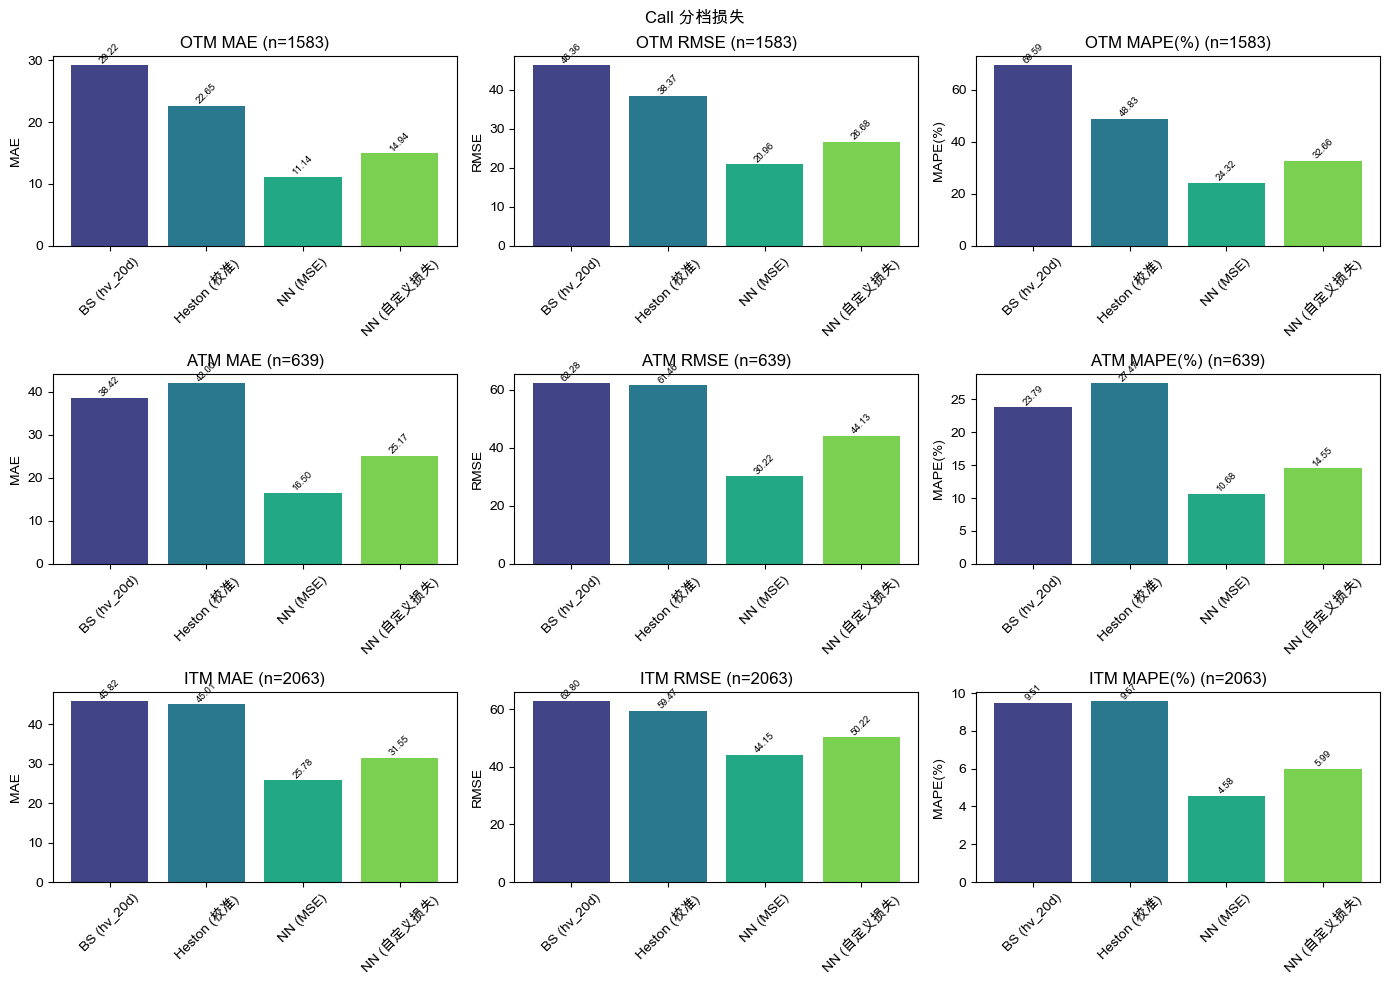

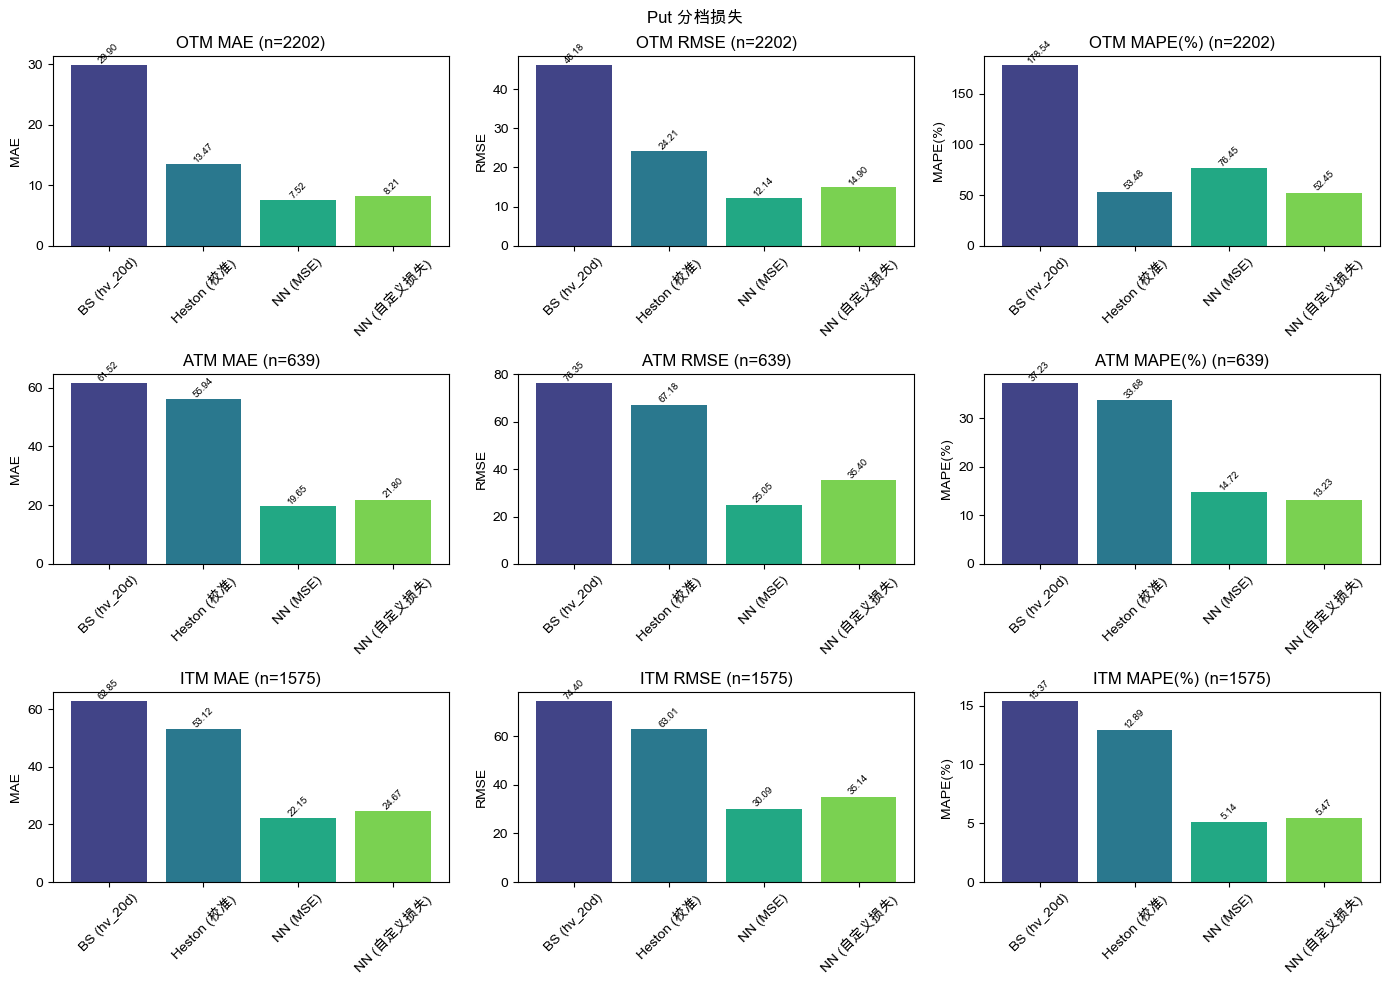

已导出 stage_3_zone_metrics.csv

--- LaTeX 格式（可直接复制到论文）---

% Call MAE
\begin{table}
\caption{Call MAE}
\begin{tabular}{lrrr}
zone & OTM & ATM & ITM \\
model &  &  &  \\
BS (hv_20d) & %.2f & %.2f & %.2f \\
Heston (校准) & %.2f & %.2f & %.2f \\
NN (MSE) & %.2f & %.2f & %.2f \\
NN (自定义损失) & %.2f & %.2f & %.2f \\
\end{tabular}
\end{table}


% Call RMSE
\begin{table}
\caption{Call RMSE}
\begin{tabular}{lrrr}
zone & OTM & ATM & ITM \\
model &  &  &  \\
BS (hv_20d) & %.2f & %.2f & %.2f \\
Heston (校准) & %.2f & %.2f & %.2f \\
NN (MSE) & %.2f & %.2f & %.2f \\
NN (自定义损失) & %.2f & %.2f & %.2f \\
\end{tabular}
\end{table}


% Call MAPE(%)
\begin{table}
\caption{Call MAPE(%)}
\begin{tabular}{lrrr}
zone & OTM & ATM & ITM \\
model &  &  &  \\
BS (hv_20d) & %.2f & %.2f & %.2f \\
Heston (校准) & %.2f & %.2f & %.2f \\
NN (MSE) & %.2f & %.2f & %.2f \\
NN (自定义损失) & %.2f & %.2f & %.2f \\
\end{tabular}
\end{table}


% Put MAE
\begin{table}
\caption{Put MAE}
\begin{tabular}{lrrr}
zone & OTM & ATM & ITM \\
model &  

In [8]:
# Call / Put 分开，正确虚值实值：Call OTM S/K<0.97, ITM S/K>1.03；Put OTM S/K>1.03, ITM S/K<0.97
m = df_test["moneyness(S/K)"].values
cp = df_test["call_put"].values  # 0=Call, 1=Put
mask_call_otm = (cp == 0) & (m < 0.97)
mask_call_atm = (cp == 0) & (m >= 0.97) & (m <= 1.03)
mask_call_itm = (cp == 0) & (m > 1.03)
mask_put_otm = (cp == 1) & (m > 1.03)
mask_put_atm = (cp == 1) & (m >= 0.97) & (m <= 1.03)
mask_put_itm = (cp == 1) & (m < 0.97)

model_preds = [
    ("BS (hv_20d)", pred_bs_test),
    ("NN (MSE)", pred_nn_mse_test),
    ("NN (自定义损失)", pred_nn_custom_test),
]
if HESTON_AVAILABLE:
    model_preds.insert(1, ("Heston (校准)", pred_heston_test))

def build_zone_summary(masks, zone_names):
    rows = []
    for zone, mask in zip(zone_names, masks):
        n = mask.sum()
        if n == 0:
            continue
        y_z = y_test[mask]
        for name, pred in model_preds:
            met = compute_metrics(y_z, pred[mask])
            rows.append({"档位": zone, "模型": name, "样本数": n, **met})
    return pd.DataFrame(rows).rename(columns={"MAPE": "MAPE(%)"})

masks_call = [mask_call_otm, mask_call_atm, mask_call_itm]
masks_put = [mask_put_otm, mask_put_atm, mask_put_itm]
summary_call = build_zone_summary(masks_call, ["OTM", "ATM", "ITM"])
summary_put = build_zone_summary(masks_put, ["OTM", "ATM", "ITM"])

# 使用 Reporter 统一可视化、导出、LaTeX
reporter_s3 = OptionPricingReporter()
reporter_s3.add_zone(
    pd.concat([summary_call.assign(option_type="Call"), summary_put.assign(option_type="Put")]),
    stage="S3",
)
reporter_s3.plot_zone(split_call_put=True)
reporter_s3.save_csv("stage_3_zone_metrics.csv", which="zone")
print("已导出 stage_3_zone_metrics.csv")
print("\n--- LaTeX 格式（可直接复制到论文）---\n")
print(reporter_s3.to_latex_zone())

In [9]:
# 分档统计已由 Reporter 在上一 cell 导出

In [10]:
rows = [
    {"模型": "BS (hv_20d)", **compute_metrics(y_test, pred_bs_test)},
    {"模型": "NN (MSE)", **compute_metrics(y_test, pred_nn_mse_test)},
    {"模型": "NN (自定义损失)", **compute_metrics(y_test, pred_nn_custom_test)},
]
if HESTON_AVAILABLE:
    rows.insert(1, {"模型": "Heston (校准)", **compute_metrics(y_test, pred_heston_test)})
summary = pd.DataFrame(rows)
summary = summary.rename(columns={"MAPE": "MAPE(%)"})
summary

,模型,MAE,RMSE,MAPE(%)
0,BS (hv_20d),42.461226,59.839011,67.360554
1,Heston (校准),35.008161,50.817080,31.511800
2,NN (MSE),16.707121,29.265946,27.653801
3,NN (自定义损失),20.188606,35.245620,23.666720


In [11]:
# 导出 stage_3 损失与测试指标，供 stage_4 对比（统一 schema：含 stage）
reporter_s3.add_overall(summary, stage="S3")
reporter_s3.save_csv("stage_3_test_metrics.csv", which="overall")
print("已导出 stage_3_test_metrics.csv")

# 训练 loss 历史
from datetime import datetime
train_loss_rows = []
for ep, loss in enumerate(nn_mse.history_["loss"], 1):
    train_loss_rows.append({"model": "NN_MSE", "epoch": ep, "loss": loss})
for ep, loss in enumerate(nn_custom.history_["loss"], 1):
    train_loss_rows.append({"model": "NN_custom", "epoch": ep, "loss": loss})
df_train_loss = pd.DataFrame(train_loss_rows)
df_train_loss["exported_at"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
df_train_loss.to_csv("stage_3_train_loss.csv", index=False)
print("已导出 stage_3_train_loss.csv")

已导出 stage_3_test_metrics.csv
已导出 stage_3_train_loss.csv


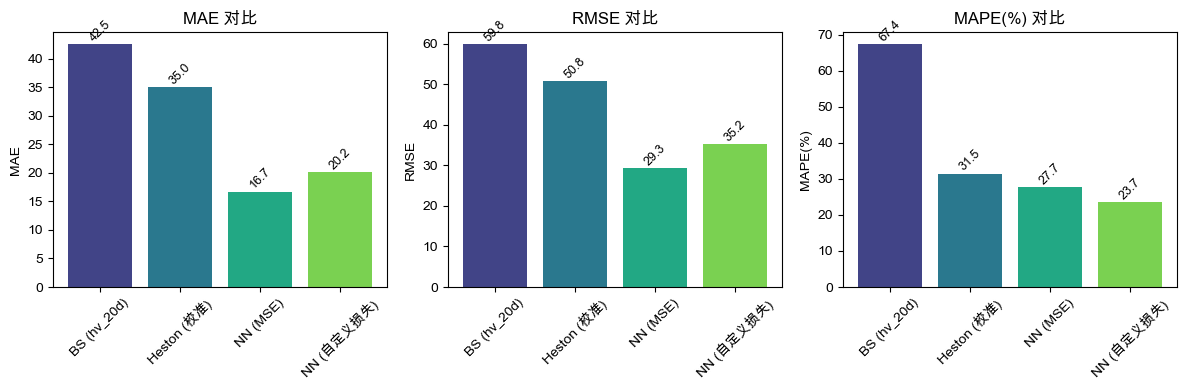

In [12]:
models = summary["模型"].tolist()
metrics = ["MAE", "RMSE", "MAPE(%)"]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(models)))
for i, m in enumerate(metrics):
    vals = summary[m].values
    bars = axes[i].bar(models, vals, color=colors)
    axes[i].set_ylabel(m)
    axes[i].set_title(f"{m} 对比")
    for b in bars:
        axes[i].text(b.get_x() + b.get_width() / 2, b.get_height(), f"{b.get_height():.1f}",
                     ha="center", va="bottom", fontsize=9, rotation=45)
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

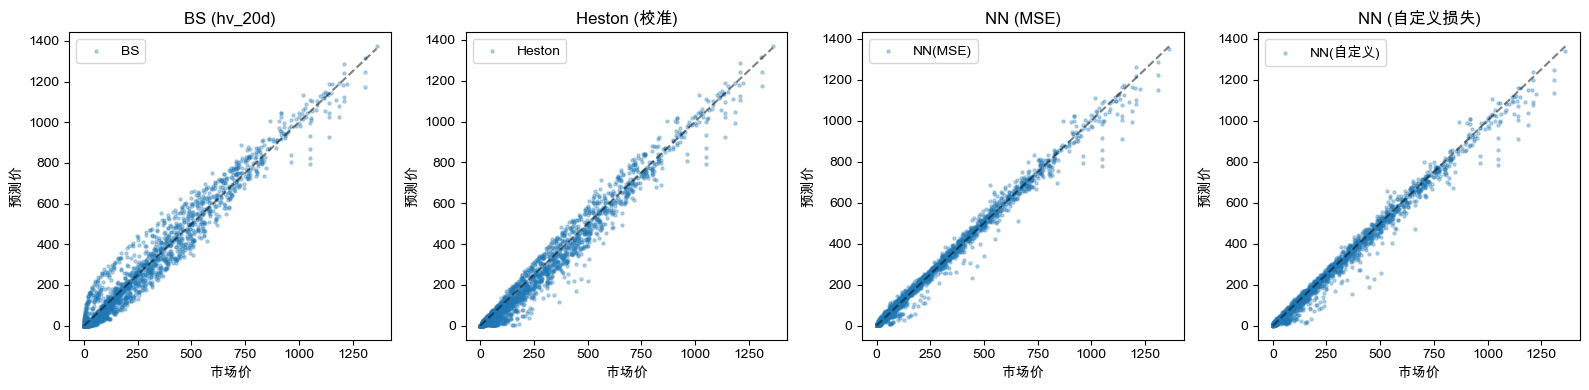

In [13]:
# 直观比较准确性
n_show = min(2000, len(df_test))
idx = np.random.RandomState(SEED).choice(len(df_test), n_show, replace=False)
yt = y_test[idx]
n_plots = 4 if HESTON_AVAILABLE else 3
fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4))
axes[0].scatter(yt, pred_bs_test[idx], alpha=0.3, s=5, label="BS")
axes[0].plot([0, yt.max()], [0, yt.max()], "k--", alpha=0.5)
axes[0].set_xlabel("市场价"); axes[0].set_ylabel("预测价"); axes[0].set_title("BS (hv_20d)"); axes[0].legend()
off = 1 if HESTON_AVAILABLE else 0
if HESTON_AVAILABLE:
    axes[1].scatter(yt, pred_heston_test[idx], alpha=0.3, s=5, label="Heston")
    axes[1].plot([0, yt.max()], [0, yt.max()], "k--", alpha=0.5)
    axes[1].set_xlabel("市场价"); axes[1].set_ylabel("预测价"); axes[1].set_title("Heston (校准)"); axes[1].legend()
axes[1 + off].scatter(yt, pred_nn_mse_test[idx], alpha=0.3, s=5, label="NN(MSE)")
axes[1 + off].plot([0, yt.max()], [0, yt.max()], "k--", alpha=0.5)
axes[1 + off].set_xlabel("市场价"); axes[1 + off].set_ylabel("预测价"); axes[1 + off].set_title("NN (MSE)"); axes[1 + off].legend()
axes[2 + off].scatter(yt, pred_nn_custom_test[idx], alpha=0.3, s=5, label="NN(自定义)")
axes[2 + off].plot([0, yt.max()], [0, yt.max()], "k--", alpha=0.5)
axes[2 + off].set_xlabel("市场价"); axes[2 + off].set_ylabel("预测价"); axes[2 + off].set_title("NN (自定义损失)"); axes[2 + off].legend()
plt.tight_layout()
plt.show()

## 预测价格反算隐含波动率对比（示例：2024-12-XX）

将各模型预测价格通过 BS 公式反算 IV，与市场 IV 对比展示。

Call iv_bs: 单点失败率 0.0% (0/25)
Call iv_nn_mse: 单点失败率 8.0% (2/25)
  ⚠ Call iv_nn_mse: 左端点缺失
Call iv_nn_custom: 单点失败率 16.0% (4/25)
  ⚠ Call iv_nn_custom: 左端点缺失
Call iv_heston: 单点失败率 0.0% (0/25)
Put iv_bs: 单点失败率 0.0% (0/38)
Put iv_nn_mse: 单点失败率 0.0% (0/38)
Put iv_nn_custom: 单点失败率 0.0% (0/38)
Put iv_heston: 单点失败率 0.0% (0/38)


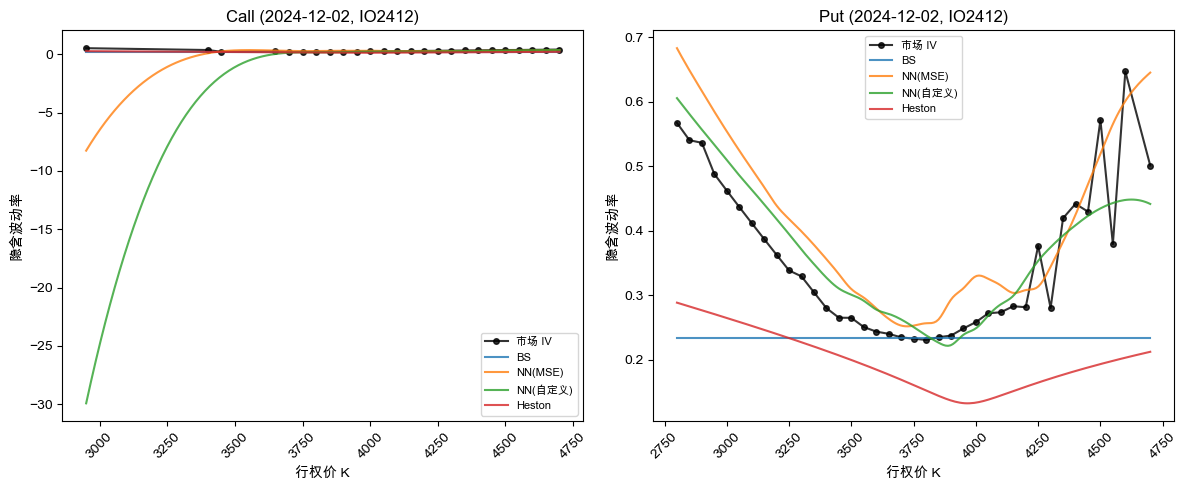

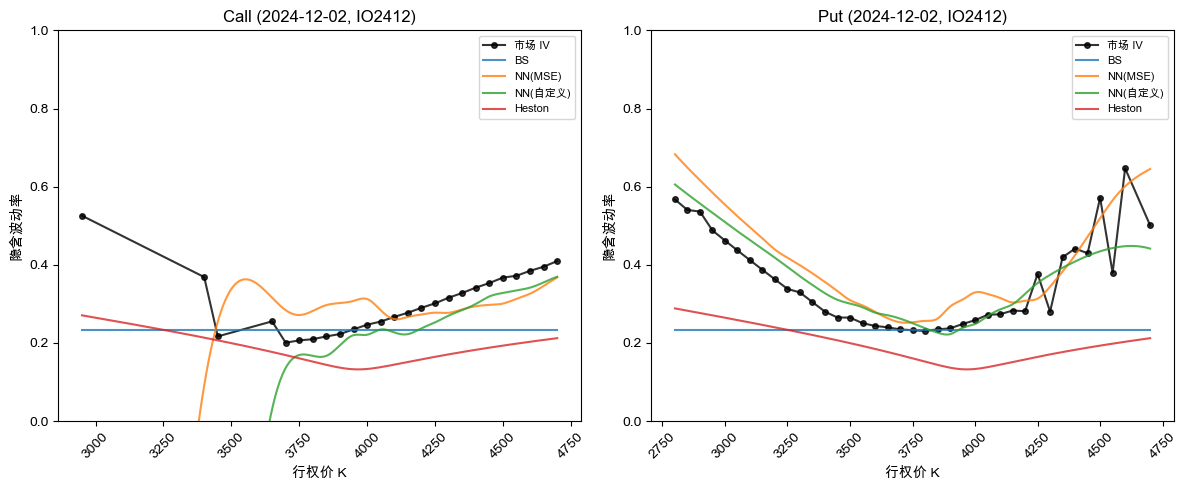

In [14]:
# 选定 2024-12-XX 作为示例，筛选该日 2412 期权，区分 Call 与 Put
date_example = "2024-12-02"
mask = (df_test["date"] == date_example) & (df_test["iv"].notna()) & (df_test["iv"] > 0.001)
df_sub = df_test[mask].copy()
if len(df_sub) == 0:
    print(f"日期 {date_example} 无有效 IV 数据，请换其他日期")
else:
    idx_sub = np.where(mask)[0]
    df_sub["pred_bs"] = pred_bs_test[idx_sub]
    df_sub["pred_nn_mse"] = pred_nn_mse_test[idx_sub]
    df_sub["pred_nn_custom"] = pred_nn_custom_test[idx_sub]
    if HESTON_AVAILABLE:
        df_sub["pred_heston"] = pred_heston_test[idx_sub]
    iv_bs = model.implied_volatility_bs_batch(df_sub, price_col="pred_bs")
    iv_nn_mse = model.implied_volatility_bs_batch(df_sub, price_col="pred_nn_mse")
    iv_nn_custom = model.implied_volatility_bs_batch(df_sub, price_col="pred_nn_custom")
    if HESTON_AVAILABLE:
        iv_heston = model.implied_volatility_bs_batch(df_sub, price_col="pred_heston")
    else:
        iv_heston = np.full(len(df_sub), np.nan)
    df_sub["iv_market"] = df_sub["iv"].values
    df_sub["iv_bs"], df_sub["iv_nn_mse"] = iv_bs, iv_nn_mse
    df_sub["iv_nn_custom"], df_sub["iv_heston"] = iv_nn_custom, iv_heston

    from scipy.interpolate import CubicSpline

    iv_cols = ["iv_bs", "iv_nn_mse", "iv_nn_custom", "iv_heston"]
    if not HESTON_AVAILABLE:
        iv_cols = [c for c in iv_cols if c != "iv_heston"]

    # 分离 Call / Put
    df_call = df_sub[df_sub["call_put"] == 0].sort_values("strike_price")
    df_put = df_sub[df_sub["call_put"] == 1].sort_values("strike_price")
    col_config = [("iv_bs", "BS"), ("iv_nn_mse", "NN(MSE)"), ("iv_nn_custom", "NN(自定义)"), ("iv_heston", "Heston")]

    def _draw_iv_panel(axes, ylim=None, do_print=True):
        for ax, d, title in [(axes[0], df_call, "Call"), (axes[1], df_put, "Put")]:
            if len(d) == 0:
                ax.text(0.5, 0.5, f"无 {title} 数据", ha="center", va="center")
                continue
            x = d["strike_price"].values
            ax.plot(x, d["iv_market"], "k-o", markersize=4, label="市场 IV", alpha=0.8)
            for col, lbl in col_config:
                if col not in iv_cols:
                    continue
                iv_raw = d[col].values
                n_total = len(iv_raw)
                n_nan = np.isnan(iv_raw).sum()
                if do_print:
                    fail_rate = n_nan / n_total if n_total > 0 else 0
                    print(f"{title} {col}: 单点失败率 {fail_rate:.1%} ({n_nan}/{n_total})")
                    first_nan = n_total > 0 and np.isnan(iv_raw[0])
                    last_nan = n_total > 0 and np.isnan(iv_raw[-1])
                    if first_nan:
                        print(f"  ⚠ {title} {col}: 左端点缺失")
                    if last_nan:
                        print(f"  ⚠ {title} {col}: 右端点缺失")
                mask_valid = ~np.isnan(iv_raw)
                n_valid = mask_valid.sum()
                if n_valid >= 2:
                    x_valid = x[mask_valid]
                    y_valid = iv_raw[mask_valid]
                    cs = CubicSpline(x_valid, y_valid)
                    x_grid = np.linspace(x.min(), x.max(), 200)
                    iv_smooth = cs(x_grid)
                    ax.plot(x_grid, iv_smooth, "-", label=lbl, alpha=0.8)
            ax.set_xlabel("行权价 K")
            ax.set_ylabel("隐含波动率")
            ax.set_title(f"{title} ({date_example}, IO2412)")
            ax.legend(loc="best", fontsize=8)
            ax.tick_params(axis="x", rotation=45)
            if ylim is not None:
                ax.set_ylim(ylim)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    _draw_iv_panel(axes)
    plt.tight_layout()
    plt.show()

    fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
    _draw_iv_panel(axes2, ylim=(0, 1), do_print=False)
    plt.tight_layout()
    plt.show()